In [2]:
# 07 - DLB versus Parkinson Analysis

#Objective:

#Determine whether slow-wave biomarkers differ between future DLB converters and future Parkinson converters.

#Groups:

#- DLB
#- PD + PD-MCI

#This analysis is restricted to converted participants.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats import anova
from statsmodels.stats.multitest import fdrcorrection
from scipy.stats import ttest_ind

In [5]:
PROJECT_ROOT = Path("..")

DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"

DLB_RESULTS_DIR = RESULTS_DIR / "dlb_vs_pd"

DLB_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

In [8]:
PROJECT_ROOT = Path("..")

DATA_FILE = PROJECT_ROOT / "data" / "processed" / "final_dataset.csv"

RESULTS_DIR = PROJECT_ROOT / "results"
DLB_RESULTS_DIR = RESULTS_DIR / "dlb_vs_pd"

DLB_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print(DATA_FILE)
print("Dataset exists:", DATA_FILE.exists())
print("Results dir exists:", DLB_RESULTS_DIR.exists())

../data/processed/final_dataset.csv
Dataset exists: True
Results dir exists: True


In [9]:
clean_df = pd.read_csv(DATA_FILE)

print(clean_df.shape)
clean_df.head()

(97, 116)


,filename,central_recording_min,frontal_recording_min,occipital_recording_min,parietal_recording_min,central_sleep_period_min,frontal_sleep_period_min,occipital_sleep_period_min,parietal_sleep_period_min,central_total_N2_valid_min,...,Âge à la PSG,UPDRS-I-2 Hallucinations,UPDRS-I Total,UPDRS-III Total -0.5,Durée de suivi,conversion_clean,Group,converter,conversion_status,conversion_subtype
0,R108_2010,487.999884,487.999884,487.999884,487.999884,463.499881,463.499881,463.499881,463.499881,331.880021,...,75.0,1.0,2.0,4.0,0.0,oui,Converti,1,Converter,DLB
1,R122_2010,500.999979,500.999979,500.999979,500.999979,459.499975,459.499975,459.499975,459.499975,213.806309,...,65.0,0.0,0.0,4.0,4.0,NaN,Non-converti,0,Non-converter,Non-converter
2,R12_2005,478.000007,478.000007,478.000007,478.000007,475.000006,475.000006,475.000006,475.000006,118.981279,...,63.0,1.0,1.0,2.0,3.0,oui,Converti,1,Converter,PD-MCI
3,R15_2004,509.999998,509.999998,509.999998,509.999998,500.499996,500.499996,500.499996,500.499996,221.466607,...,69.0,0.0,1.0,3.0,8.0,oui,Converti,1,Converter,PD
4,R165_2014,473.999968,473.999968,473.999968,473.999968,468.999963,468.999963,468.999963,468.999963,255.729338,...,68.0,0.0,0.0,1.0,9.0,NaN,Non-converti,0,Non-converter,Non-converter


In [10]:
clean_df["conversion_subtype"].value_counts()

conversion_subtype
Non-converter    60
DLB              20
PD                9
PD-MCI            8
Name: count, dtype: int64

In [11]:
analysis_df = clean_df.copy()

analysis_df = analysis_df[
    analysis_df["conversion_subtype"] != "Non-converter"
].copy()

analysis_df["clinical_group"] = (
    analysis_df["conversion_subtype"]
    .replace({
        "PD": "Parkinson",
        "PD-MCI": "Parkinson",
        "DLB": "DLB",
    })
)

analysis_df["clinical_group"].value_counts()

clinical_group
DLB          20
Parkinson    17
Name: count, dtype: int64

In [12]:
group_counts = analysis_df["clinical_group"].value_counts()

group_counts.to_csv(
    DLB_RESULTS_DIR / "group_counts.csv"
)

group_counts

clinical_group
DLB          20
Parkinson    17
Name: count, dtype: int64

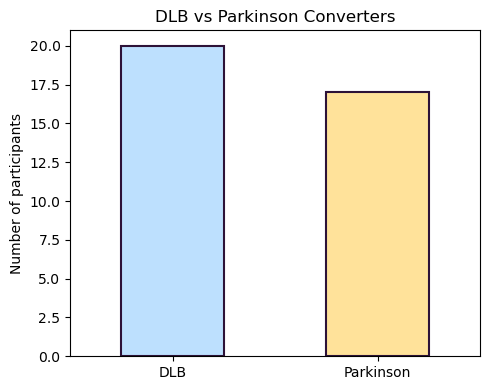

In [13]:
fig, ax = plt.subplots(figsize=(5, 4))

group_counts.plot(
    kind="bar",
    color=["#BDE0FE", "#FFE29A"],
    edgecolor="#2D1238",
    linewidth=1.5,
    ax=ax,
)

ax.set_ylabel("Number of participants")
ax.set_xlabel("")
ax.set_title("DLB vs Parkinson Converters")

ax.tick_params(axis="x", rotation=0)

plt.tight_layout()

plt.savefig(
    DLB_RESULTS_DIR / "group_counts.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [14]:
clinical_summary = analysis_df.groupby(
    "clinical_group"
)[
    [
        "UPDRS-I Total",
        "UPDRS-III Total -0.5",
    ]
].describe()

clinical_summary

UPDRS-I Total                                            \
                       count   mean       std  min  25%  50%  75%  max   
clinical_group                                                           
DLB                     20.0  1.050  1.037456  0.0  0.0  1.0  2.0  3.0   
Parkinson               16.0  0.625  0.562731  0.0  0.0  0.5  1.0  2.0   

               UPDRS-III Total -0.5                                             
                              count  mean       std  min  25%  50%   75%   max  
clinical_group                                                                  
DLB                            20.0  4.90  3.654845  0.0  2.0  3.5  8.00  13.0  
Parkinson                      16.0  5.25  4.328202  0.0  2.0  3.5  8.25  15.0

In [16]:
robust_features = [
    "central_total_N3_pkpk_amp_uV",
    "central_total_freq_Hz",
    "central_total_trans_freq_Hz",
    "frontal_total_slope_0_min",
    "frontal_total_sw_count",
    "occipital_total_N2_pkpk_amp_uV",
    "occipital_total_N3_pkpk_amp_uV",
    "occipital_total_slope_0_min",
    "parietal_total_N2_freq_Hz",
    "parietal_total_sw_count",
]
missing_features = [
    feature for feature in robust_features
    if feature not in analysis_df.columns
]

missing_features

[]

/var/folders/b7/gqjljns95gn1_syr6whltf700000gn/T/ipykernel_31434/2928700898.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


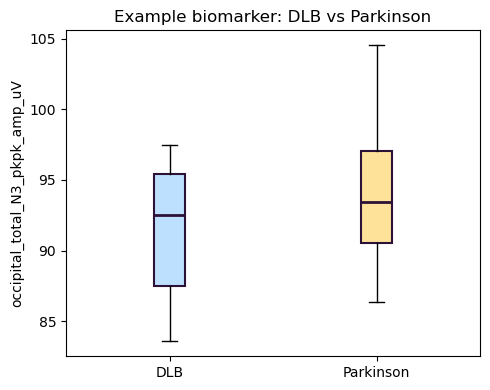

In [17]:
feature = "occipital_total_N3_pkpk_amp_uV"

groups = [
    analysis_df.loc[
        analysis_df["clinical_group"] == "DLB",
        feature
    ].dropna(),
    analysis_df.loc[
        analysis_df["clinical_group"] == "Parkinson",
        feature
    ].dropna(),
]

fig, ax = plt.subplots(figsize=(5, 4))

bp = ax.boxplot(
    groups,
    labels=["DLB", "Parkinson"],
    patch_artist=True,
)

colors = ["#BDE0FE", "#FFE29A"]

for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_edgecolor("#2D1238")
    patch.set_linewidth(1.5)

for median in bp["medians"]:
    median.set_color("#2D1238")
    median.set_linewidth(2)

ax.set_ylabel(feature)
ax.set_title("Example biomarker: DLB vs Parkinson")

plt.tight_layout()

plt.savefig(
    DLB_RESULTS_DIR / f"boxplot_{feature}.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

/var/folders/b7/gqjljns95gn1_syr6whltf700000gn/T/ipykernel_31434/2056116591.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


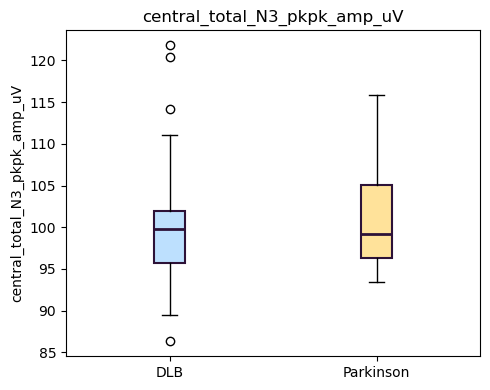

/var/folders/b7/gqjljns95gn1_syr6whltf700000gn/T/ipykernel_31434/2056116591.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


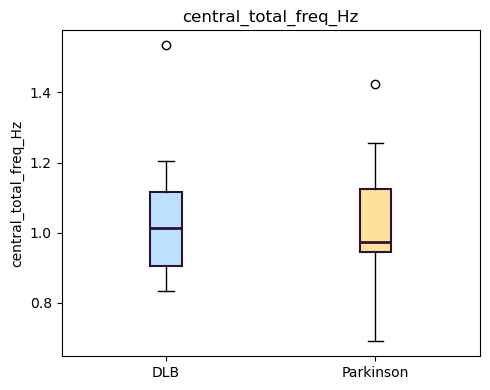

/var/folders/b7/gqjljns95gn1_syr6whltf700000gn/T/ipykernel_31434/2056116591.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


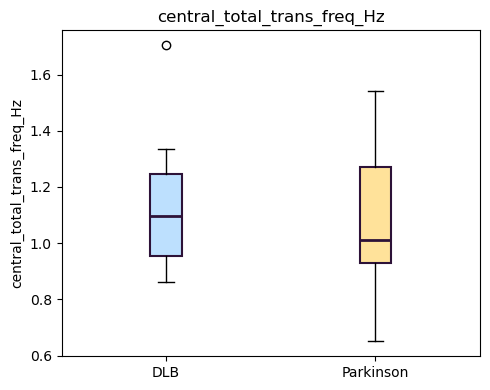

/var/folders/b7/gqjljns95gn1_syr6whltf700000gn/T/ipykernel_31434/2056116591.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


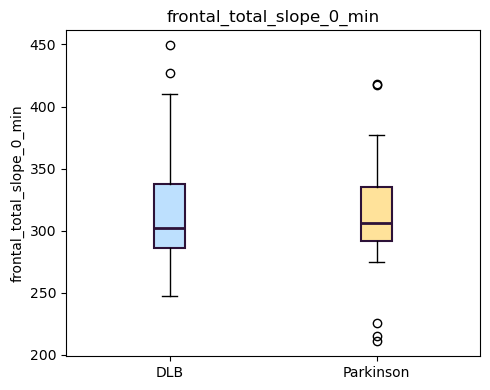

/var/folders/b7/gqjljns95gn1_syr6whltf700000gn/T/ipykernel_31434/2056116591.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


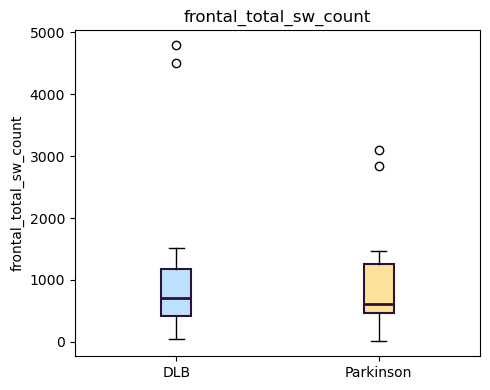

/var/folders/b7/gqjljns95gn1_syr6whltf700000gn/T/ipykernel_31434/2056116591.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


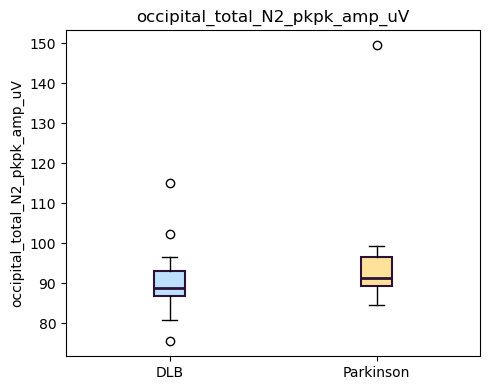

/var/folders/b7/gqjljns95gn1_syr6whltf700000gn/T/ipykernel_31434/2056116591.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


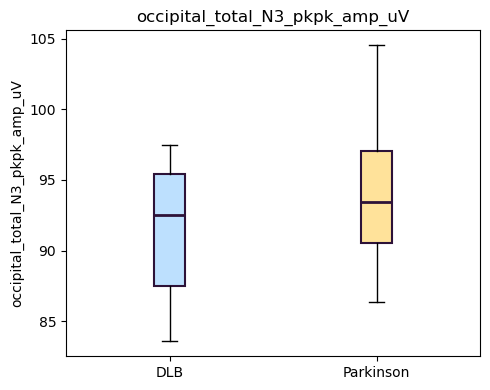

/var/folders/b7/gqjljns95gn1_syr6whltf700000gn/T/ipykernel_31434/2056116591.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


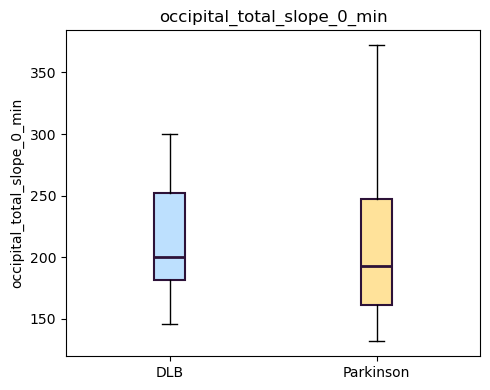

/var/folders/b7/gqjljns95gn1_syr6whltf700000gn/T/ipykernel_31434/2056116591.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


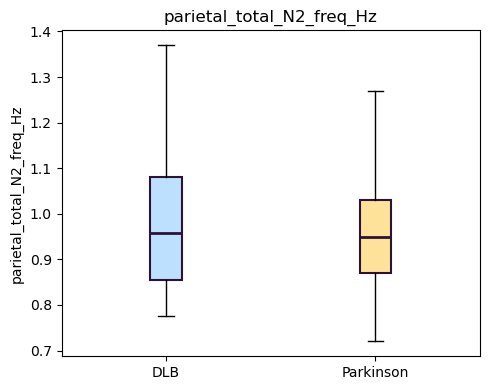

/var/folders/b7/gqjljns95gn1_syr6whltf700000gn/T/ipykernel_31434/2056116591.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


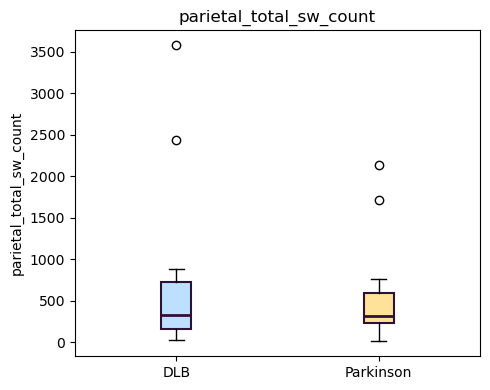

In [18]:
for feature in robust_features:

    groups = [
        analysis_df.loc[
            analysis_df["clinical_group"] == "DLB",
            feature
        ].dropna(),
        analysis_df.loc[
            analysis_df["clinical_group"] == "Parkinson",
            feature
        ].dropna(),
    ]

    fig, ax = plt.subplots(figsize=(5, 4))

    bp = ax.boxplot(
        groups,
        labels=["DLB", "Parkinson"],
        patch_artist=True,
    )

    colors = ["#BDE0FE", "#FFE29A"]

    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_edgecolor("#2D1238")
        patch.set_linewidth(1.5)

    for median in bp["medians"]:
        median.set_color("#2D1238")
        median.set_linewidth(2)

    ax.set_ylabel(feature)
    ax.set_title(feature)

    plt.tight_layout()

    plt.savefig(
        DLB_RESULTS_DIR / f"boxplot_{feature}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [19]:
# jusqu'à là, on a fait de la visulaition des caractériqtiques d'ondes lentes, maintenant, on va faire la disctintion entre ces critères pour les deux types de convertisseurs 
# 07 - DLB versus Parkinson Analysis

#Objective:

#Determine whether slow-wave biomarkers differ between future DLB converters and future Parkinson converters.

#Groups:

#- DLB
#- PD + PD-MCI


In [20]:
# 07 - DLB versus Parkinson Analysis

#Objective:

#Determine whether slow-wave biomarkers differ between future DLB converters and future Parkinson converters.

#Groups:

#- DLB
#- PD + PD-MCI



In [22]:
import pandas as pd
import numpy as np

from pathlib import Path

import matplotlib.pyplot as plt


import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats import anova
from statsmodels.stats.multitest import fdrcorrection

from scipy.stats import ttest_ind

In [23]:
analysis_df.shape

(37, 117)

In [24]:
analysis_df["clinical_group"].value_counts()

clinical_group
DLB          20
Parkinson    17
Name: count, dtype: int64

In [25]:
analysis_df.columns.tolist()

['filename',
 'central_recording_min',
 'frontal_recording_min',
 'occipital_recording_min',
 'parietal_recording_min',
 'central_sleep_period_min',
 'frontal_sleep_period_min',
 'occipital_sleep_period_min',
 'parietal_sleep_period_min',
 'central_total_N2_valid_min',
 'frontal_total_N2_valid_min',
 'occipital_total_N2_valid_min',
 'parietal_total_N2_valid_min',
 'central_total_N3_valid_min',
 'frontal_total_N3_valid_min',
 'occipital_total_N3_valid_min',
 'parietal_total_N3_valid_min',
 'central_total_valid_min',
 'frontal_total_valid_min',
 'occipital_total_valid_min',
 'parietal_total_valid_min',
 'central_total_N2_sw_count',
 'frontal_total_N2_sw_count',
 'occipital_total_N2_sw_count',
 'parietal_total_N2_sw_count',
 'central_total_N3_sw_count',
 'frontal_total_N3_sw_count',
 'occipital_total_N3_sw_count',
 'parietal_total_N3_sw_count',
 'central_total_sw_count',
 'frontal_total_sw_count',
 'occipital_total_sw_count',
 'parietal_total_sw_count',
 'central_total_N2_sw_sec',
 'front

In [26]:
robust_features = [
    "central_total_N3_pkpk_amp_uV",
    "central_total_freq_Hz",
    "central_total_trans_freq_Hz",
    "frontal_total_slope_0_min",
    "frontal_total_sw_count",
    "occipital_total_N2_pkpk_amp_uV",
    "occipital_total_N3_pkpk_amp_uV",
    "occipital_total_slope_0_min",
    "parietal_total_N2_freq_Hz",
    "parietal_total_sw_count",
]

In [27]:
feature = "occipital_total_N3_pkpk_amp_uV"


In [28]:
import statsmodels.formula.api as smf

In [30]:
model = smf.ols(
    f'Q("{feature}") ~ C(clinical_group) + Q("UPDRS-I Total") + Q("UPDRS-III Total -0.5")',
    data=analysis_df
).fit()

In [31]:
from statsmodels.stats.anova import anova_lm

In [32]:
anova_lm(
    model,
    typ=2
)

,sum_sq,df,F,PR(>F)
C(clinical_group),144.208602,1.0,7.037708,0.014533
"Q(""UPDRS-I Total"")",98.714431,1.0,4.817489,0.039019
"Q(""UPDRS-III Total -0.5"")",46.957516,1.0,2.291634,0.144308
Residual,450.798618,22.0,NaN,NaN


In [33]:
# on automatise pour les 10 biomarqueurs : 
from statsmodels.stats.anova import anova_lm

results = []

for feature in robust_features:

    model = smf.ols(
        f'Q("{feature}") ~ C(clinical_group) + Q("UPDRS-I Total") + Q("UPDRS-III Total -0.5")',
        data=analysis_df
    ).fit()

    table = anova_lm(
        model,
        typ=2
    )

    p_value = table.loc[
        "C(clinical_group)",
        "PR(>F)"
    ]

    f_value = table.loc[
        "C(clinical_group)",
        "F"
    ]

    results.append(
        {
            "feature": feature,
            "F": f_value,
            "p_value": p_value,
        }
    )
    

In [34]:
ancova_results = pd.DataFrame(results)

ancova_results

,feature,F,p_value
0,central_total_N3_pkpk_amp_uV,0.169540,0.683771
1,central_total_freq_Hz,0.689116,0.412616
2,central_total_trans_freq_Hz,0.925439,0.343264
3,frontal_total_slope_0_min,0.511308,0.479758
4,frontal_total_sw_count,0.003302,0.954530
5,occipital_total_N2_pkpk_amp_uV,2.773398,0.107405
6,occipital_total_N3_pkpk_amp_uV,7.037708,0.014533
7,occipital_total_slope_0_min,0.020616,0.886898
8,parietal_total_N2_freq_Hz,0.058008,0.811210
9,parietal_total_sw_count,0.043772,0.835604


In [35]:
# on trie
ancova_results = (
    ancova_results
    .sort_values("p_value")
)

ancova_results

,feature,F,p_value
6,occipital_total_N3_pkpk_amp_uV,7.037708,0.014533
5,occipital_total_N2_pkpk_amp_uV,2.773398,0.107405
2,central_total_trans_freq_Hz,0.925439,0.343264
1,central_total_freq_Hz,0.689116,0.412616
3,frontal_total_slope_0_min,0.511308,0.479758
0,central_total_N3_pkpk_amp_uV,0.169540,0.683771
8,parietal_total_N2_freq_Hz,0.058008,0.811210
9,parietal_total_sw_count,0.043772,0.835604
7,occipital_total_slope_0_min,0.020616,0.886898
4,frontal_total_sw_count,0.003302,0.954530


In [36]:
from statsmodels.stats.multitest import fdrcorrection

In [37]:
reject, q_values = fdrcorrection(
    ancova_results["p_value"]
)

In [38]:
ancova_results["q_value"] = q_values

ancova_results["significant"] = reject

In [39]:
ancova_results

,feature,F,p_value,q_value,significant
6,occipital_total_N3_pkpk_amp_uV,7.037708,0.014533,0.145331,False
5,occipital_total_N2_pkpk_amp_uV,2.773398,0.107405,0.537027,False
2,central_total_trans_freq_Hz,0.925439,0.343264,0.954530,False
1,central_total_freq_Hz,0.689116,0.412616,0.954530,False
3,frontal_total_slope_0_min,0.511308,0.479758,0.954530,False
0,central_total_N3_pkpk_amp_uV,0.169540,0.683771,0.954530,False
8,parietal_total_N2_freq_Hz,0.058008,0.811210,0.954530,False
9,parietal_total_sw_count,0.043772,0.835604,0.954530,False
7,occipital_total_slope_0_min,0.020616,0.886898,0.954530,False
4,frontal_total_sw_count,0.003302,0.954530,0.954530,False


In [40]:
ancova_results.to_csv(
    DLB_RESULTS_DIR /
    "ancova_dlb_vs_pd.csv",
    index=False
)

In [41]:
# on visualise 
ancova_results["minus_log10_q"] = (
    -np.log10(
        ancova_results["q_value"]
    )
)

In [43]:
ancova_results

,feature,F,p_value,q_value,significant,minus_log10_q
6,occipital_total_N3_pkpk_amp_uV,7.037708,0.014533,0.145331,False,0.837641
5,occipital_total_N2_pkpk_amp_uV,2.773398,0.107405,0.537027,False,0.270004
2,central_total_trans_freq_Hz,0.925439,0.343264,0.954530,False,0.020210
1,central_total_freq_Hz,0.689116,0.412616,0.954530,False,0.020210
3,frontal_total_slope_0_min,0.511308,0.479758,0.954530,False,0.020210
0,central_total_N3_pkpk_amp_uV,0.169540,0.683771,0.954530,False,0.020210
8,parietal_total_N2_freq_Hz,0.058008,0.811210,0.954530,False,0.020210
9,parietal_total_sw_count,0.043772,0.835604,0.954530,False,0.020210
7,occipital_total_slope_0_min,0.020616,0.886898,0.954530,False,0.020210
4,frontal_total_sw_count,0.003302,0.954530,0.954530,False,0.020210


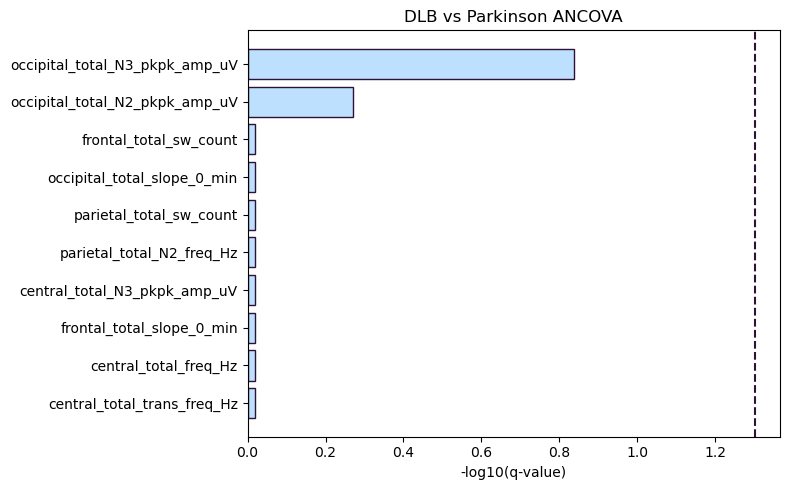

In [42]:
fig, ax = plt.subplots(
    figsize=(8, 5)
)

plot_df = (
    ancova_results
    .sort_values("minus_log10_q")
)

ax.barh(
    plot_df["feature"],
    plot_df["minus_log10_q"],
    color="#BDE0FE",
    edgecolor="#2D1238",
)

ax.axvline(
    -np.log10(0.05),
    linestyle="--",
    color="#2D1238"
)

ax.set_xlabel("-log10(q-value)")

ax.set_title(
    "DLB vs Parkinson ANCOVA"
)

plt.tight_layout()

plt.savefig(
    DLB_RESULTS_DIR /
    "ancova_dlb_vs_pd.png",
    dpi=300
)

plt.show()

In [44]:
def cohens_d(x1, x2):

    n1 = len(x1)
    n2 = len(x2)

    pooled_sd = np.sqrt(
        (
            ((n1 - 1) * np.var(x1, ddof=1))
            +
            ((n2 - 1) * np.var(x2, ddof=1))
        )
        /
        (n1 + n2 - 2)
    )

    return (
        np.mean(x1)
        -
        np.mean(x2)
    ) / pooled_sd

In [45]:
effect_sizes = []

for feature in robust_features:

    dlb = analysis_df.loc[
        analysis_df["clinical_group"] == "DLB",
        feature
    ].dropna()

    pd_group = analysis_df.loc[
        analysis_df["clinical_group"] == "Parkinson",
        feature
    ].dropna()

    d = cohens_d(
        dlb,
        pd_group
    )

    effect_sizes.append(
        {
            "feature": feature,
            "cohens_d": d
        }
    )

effect_sizes = pd.DataFrame(
    effect_sizes
)

effect_sizes.sort_values(
    "cohens_d",
    key=np.abs,
    ascending=False
)

,feature,cohens_d
6,occipital_total_N3_pkpk_amp_uV,-0.620141
5,occipital_total_N2_pkpk_amp_uV,-0.446280
2,central_total_trans_freq_Hz,0.280927
3,frontal_total_slope_0_min,0.215082
1,central_total_freq_Hz,0.191505
9,parietal_total_sw_count,0.182261
8,parietal_total_N2_freq_Hz,0.134182
4,frontal_total_sw_count,0.130308
7,occipital_total_slope_0_min,0.053476
0,central_total_N3_pkpk_amp_uV,-0.027518


In [46]:
# deux biomaruqueurs ressortenet pik to pim amplitude e occipital en N@ et N3, mais surtout N#
#Amplitude N3 occipitale plus faible chez DLB
#Amplitude N2 occipitale plus faible chez DLB

#No biomarker survived FDR correction. However, exploratory analyses revealed
#moderate effect sizes for occipital slow-wave amplitude measures. 
#Both N2 and N3 occipital peak-to-peak amplitudes were lower in future 
#DLB converters than in future Parkinson converters, suggesting a potential 
#occipital signature associated with conversion subtype.
